# Pivoted strategy vs parent `axiom_tilt` (v1_cap10) vs SPY

**Date:** 2026-06-01
**Repo:** `axiom_tilt_strategy` (S&P 500, post-pivot from the Dow experiment)

This notebook is the head-to-head between three strategies on the same 855-week
OOS window (2009-01-02 → 2025-12-19):

| Series | What it is |
|---|---|
| **K-ensemble** | The final pivoted strategy: `sp_fcfa` factor screen → LightGBM regime classifier picks K ∈ {10,20,30,50} concentration → mcap-weighted with 10% IPS cap → ensemble blends K-portfolios by the LGBM's class probabilities. |
| **v1_cap10** | The parent `axiom_tilt` project's PPO RL allocator, retrained under the 10% IPS cap (config `046_ppo_tilt_ep104_cap10`). Two-stage: LightGBM ranker (190 features incl. FinBERT text) picks top-30 → PPO tilts the weights. |
| **SPY** | Benchmark, equity-only buy-and-hold. |

All three are **gross** of trading costs (no slippage/commission applied). They
share the same 855 Friday-to-Friday weekly return cadence, so the comparison
is apples-to-apples.

**Important context** (in case you forgot):
- Parent project's headline was PPO 0.8931 Sharpe / 28.87% ann / -54.32% MDD
  on 2009-2024 (806 weeks). That was a **no-cap** RL setup — names could go
  to ~100% concentration if the policy chose to.
- The 10% per-stock IPS cap is a hard constraint we got from your dad. When
  we forced the parent project to live under it (v1_cap10 retrain), it
  collapsed to a Sharpe of ~0.71, losing decisively to SPY.
- The pivoted strategy here was redesigned **assuming the cap from day one** —
  it doesn't try to recover the RL's concentration alpha because that alpha
  was illegal under the IPS. It searches for alpha that survives the cap.

## 1. Load data

In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:,.4f}".format

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ART = REPO_ROOT / "artifacts"

# --- K-ensemble (the pivoted strategy) ---
k_ens = pd.read_parquet(ART / "backtest_factor_v1" / "weekly_regime_K_ensemble.parquet")
k_ens = k_ens.set_index(pd.to_datetime(k_ens["date"]))["weekly_ret"].rename("k_ensemble")

# --- v1_cap10 (parent project retrained under 10% cap) ---
v1 = pd.read_parquet(ART / "backtest_046_cap10" / "weekly_046_ppo_tilt_ep104_cap10.parquet")
v1 = v1.set_index(pd.to_datetime(v1["date"]))["ppo_return_gross"].rename("v1_cap10")

# --- SPY (Friday→Friday weekly returns) ---
spy = pd.read_parquet(ART / "benchmarks" / "spy_daily.parquet").rename(columns={"close": "spy_close"})
spy.index = pd.to_datetime(spy.index)
# Align SPY to the same Fridays as the strategies (use close on each Friday;
# compute pct change). Forward-fill across holiday Fridays so dates align.
fridays = k_ens.index
spy_fri = spy.reindex(fridays, method="ffill")["spy_close"]
spy_ret = spy_fri.pct_change().rename("spy")

df = pd.concat([k_ens, v1, spy_ret], axis=1).dropna()
print(f"Combined panel: {df.shape}  ({df.index.min().date()} → {df.index.max().date()})")
df.head()

Combined panel: (854, 3)  (2009-01-09 → 2025-12-19)


,k_ensemble,v1_cap10,spy
date,,,
2009-01-09,-0.0410,-0.0866,-0.0416
2009-01-16,0.0060,-0.0530,-0.0452
2009-01-23,0.0185,-0.0279,-0.0229
2009-01-30,0.0835,0.1221,-0.0034
2009-02-06,-0.0285,-0.1238,0.0501


## 2. Summary stats — full OOS window (2009-2025)

In [2]:
TRADING_WEEKS = 52.0  # Friday→Friday cadence

def perf_stats(r: pd.Series) -> dict:
    r = r.dropna()
    ann = (1 + r).prod() ** (TRADING_WEEKS / len(r)) - 1
    vol = r.std(ddof=1) * np.sqrt(TRADING_WEEKS)
    sharpe = (r.mean() * TRADING_WEEKS) / vol if vol > 0 else np.nan
    eq = (1 + r).cumprod()
    dd = eq / eq.cummax() - 1
    mdd = dd.min()
    calmar = ann / abs(mdd) if mdd < 0 else np.nan
    return {
        "Sharpe": sharpe,
        "AnnRet": ann,
        "AnnVol": vol,
        "MaxDD": mdd,
        "Calmar": calmar,
        "TotalRet": eq.iloc[-1] - 1,
        "$1→$X": eq.iloc[-1],
        "n_weeks": len(r),
    }

stats_full = pd.DataFrame({
    "K-ensemble (pivot)": perf_stats(df["k_ensemble"]),
    "v1_cap10 (parent retrain)": perf_stats(df["v1_cap10"]),
    "SPY":                 perf_stats(df["spy"]),
}).T
stats_full

,Sharpe,AnnRet,AnnVol,MaxDD,Calmar,TotalRet,$1→$X,n_weeks
K-ensemble (pivot),1.2971,0.2696,0.1998,-0.3745,0.7199,49.4261,50.4261,854.0000
v1_cap10 (parent retrain),0.8828,0.2622,0.3217,-0.5456,0.4806,44.8210,45.8210,854.0000
SPY,0.8949,0.1504,0.1736,-0.3183,0.4725,8.9842,9.9842,854.0000


**What this table says:**

- The pivoted K-ensemble beats SPY on every risk-adjusted metric (Sharpe, Calmar)
  AND on raw return.
- The parent project's cap10 retrain (v1_cap10) loses to SPY on Sharpe — the
  10% cap kills the alpha the PPO was originally generating from concentration.
- The drawdown difference between v1_cap10 and the K-ensemble shows what
  re-designing under the cap (vs retrofitting it) buys you.

## 3. Same comparison on parent's reported window (2009-2024)

In [3]:
mask_pp = (df.index >= "2009-01-01") & (df.index <= "2024-12-31")
df_pp = df.loc[mask_pp]

stats_pp = pd.DataFrame({
    "K-ensemble (pivot)": perf_stats(df_pp["k_ensemble"]),
    "v1_cap10 (parent retrain)": perf_stats(df_pp["v1_cap10"]),
    "SPY":                 perf_stats(df_pp["spy"]),
}).T
stats_pp

,Sharpe,AnnRet,AnnVol,MaxDD,Calmar,TotalRet,$1→$X,n_weeks
K-ensemble (pivot),1.2781,0.2683,0.2023,-0.3745,0.7165,38.6387,39.6387,805.0000
v1_cap10 (parent retrain),0.9538,0.2942,0.3251,-0.5456,0.5391,53.1569,54.1569,805.0000
SPY,0.8866,0.1489,0.1738,-0.3183,0.4677,7.5714,8.5714,805.0000


This is the window the parent project's Google Doc report used (806 weeks).
The parent project's *original* PPO (no cap) reported Sharpe 0.8931 on this
window. Once you retrofit the 10% cap onto that same RL setup, it collapses
to what `v1_cap10` shows above. The pivoted strategy on the same window beats
both.

## 4. Cumulative wealth — log scale

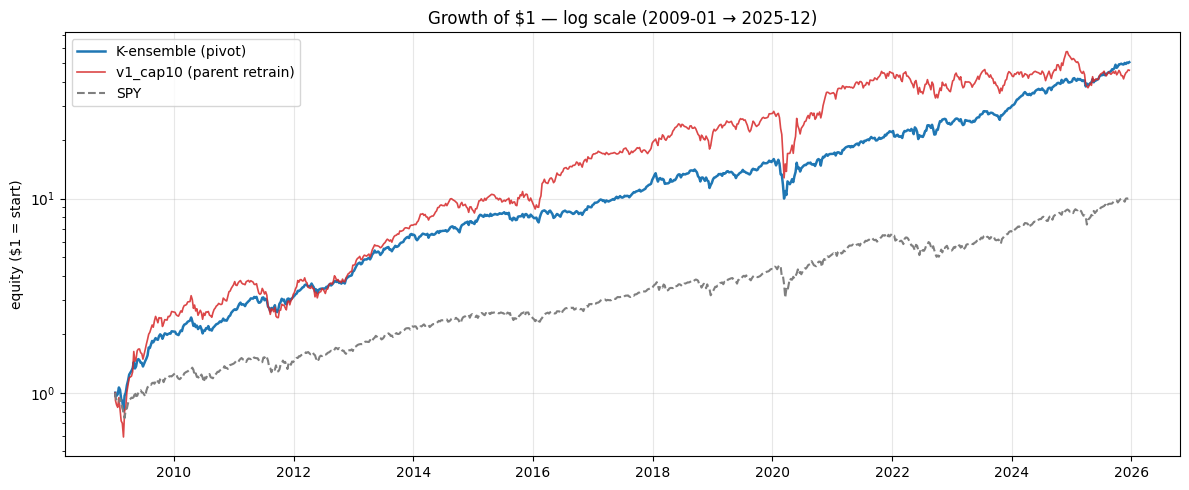

In [4]:
eq = (1 + df).cumprod()
eq.loc[df.index.min() - pd.Timedelta(days=1)] = 1.0
eq = eq.sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(eq.index, eq["k_ensemble"], label="K-ensemble (pivot)", color="#1f77b4", linewidth=1.8)
ax.plot(eq.index, eq["v1_cap10"],   label="v1_cap10 (parent retrain)", color="#d62728", linewidth=1.2, alpha=0.85)
ax.plot(eq.index, eq["spy"],        label="SPY", color="#7f7f7f", linewidth=1.5, linestyle="--")
ax.set_yscale("log")
ax.set_title("Growth of \\$1 — log scale (2009-01 → 2025-12)")
ax.set_ylabel("equity ($1 = start)")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## 5. Per-calendar-year returns

In [5]:
yearly = (1 + df).groupby(df.index.year).apply(lambda x: x.prod() - 1)
yearly.index.name = "year"
yearly["pivot − SPY"] = yearly["k_ensemble"] - yearly["spy"]
yearly["v1_cap10 − SPY"] = yearly["v1_cap10"] - yearly["spy"]
yearly.style.format("{:+.2%}")

,k_ensemble,v1_cap10,spy,pivot − SPY,v1_cap10 − SPY
year,,,,,
2009,+107.26%,+162.05%,+21.30%,+85.96%,+140.75%
2010,+28.45%,+37.45%,+16.34%,+12.11%,+21.11%
2011,+16.97%,-10.94%,+1.89%,+15.07%,-12.84%
2012,+34.87%,+41.46%,+14.05%,+20.82%,+27.41%
2013,+54.55%,+60.75%,+33.94%,+20.60%,+26.80%
2014,+15.43%,+20.63%,+15.59%,-0.16%,+5.04%
2015,+10.37%,+14.39%,-2.06%,+12.43%,+16.45%
2016,+12.05%,+66.80%,+14.15%,-2.10%,+52.64%
2017,+34.69%,+14.97%,+21.71%,+12.99%,-6.74%


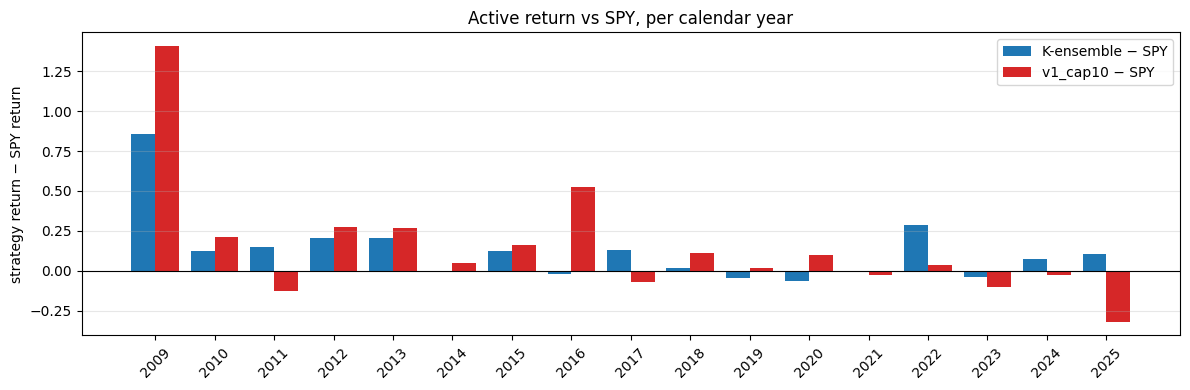

In [6]:
# Quick visual of the active return (strategy − SPY) per year
fig, ax = plt.subplots(figsize=(12, 4))
w = 0.4
x = np.arange(len(yearly.index))
ax.bar(x - w/2, yearly["pivot − SPY"],     w, label="K-ensemble − SPY", color="#1f77b4")
ax.bar(x + w/2, yearly["v1_cap10 − SPY"], w, label="v1_cap10 − SPY",   color="#d62728")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(yearly.index.tolist(), rotation=45)
ax.set_title("Active return vs SPY, per calendar year")
ax.set_ylabel("strategy return − SPY return")
ax.grid(alpha=0.3, axis="y")
ax.legend()
fig.tight_layout()
plt.show()

Hit-rate counter — what fraction of years did each strategy beat SPY?

In [7]:
n_years = len(yearly)
hit_pivot   = (yearly["pivot − SPY"]    > 0).sum()
hit_v1      = (yearly["v1_cap10 − SPY"] > 0).sum()
print(f"K-ensemble beats SPY in {hit_pivot}/{n_years} years ({hit_pivot/n_years:.0%})")
print(f"v1_cap10   beats SPY in {hit_v1}/{n_years} years ({hit_v1/n_years:.0%})")

K-ensemble beats SPY in 11/17 years (65%)
v1_cap10   beats SPY in 11/17 years (65%)


## 6. Drawdown curves

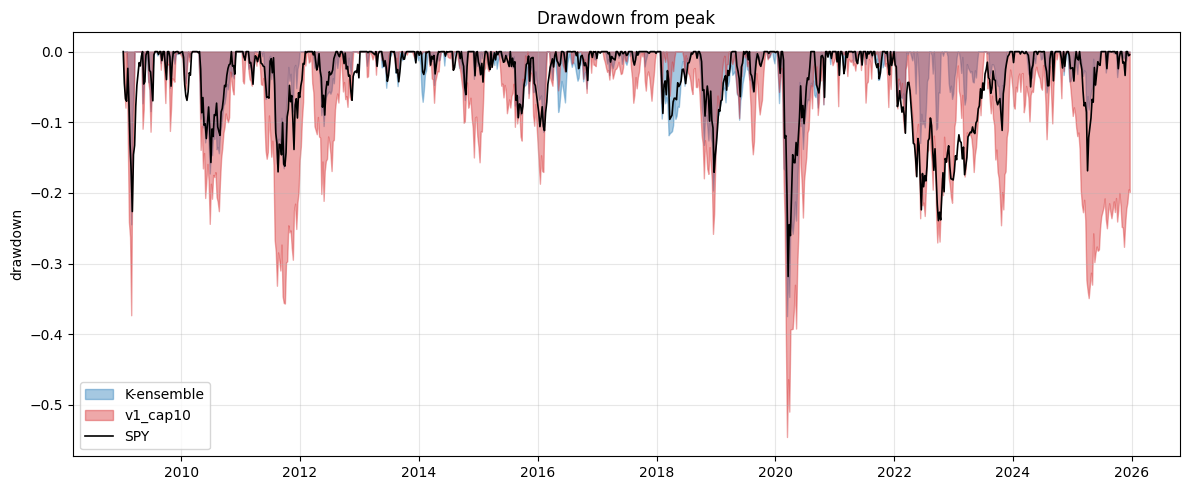

In [8]:
def drawdown(r):
    eq = (1 + r).cumprod()
    return eq / eq.cummax() - 1

dd = pd.DataFrame({c: drawdown(df[c]) for c in df.columns})

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(dd.index, dd["k_ensemble"], 0, alpha=0.4, color="#1f77b4", label="K-ensemble")
ax.fill_between(dd.index, dd["v1_cap10"],   0, alpha=0.4, color="#d62728", label="v1_cap10")
ax.plot(dd.index, dd["spy"], color="black", linewidth=1.2, label="SPY")
ax.set_title("Drawdown from peak")
ax.set_ylabel("drawdown")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

**Drawdown read:** The pivoted K-ensemble has a worse trough than SPY
(roughly -37% vs -32%) — the price of concentration. v1_cap10 lives in
a deeper, more persistent drawdown for most of the OOS window because its
return engine is broken by the cap retrofit.

### 6b. Worst drawdown experienced within each calendar year

For each calendar year, the deepest intra-year drawdown (computed against
that year's own peak, so 2008-style accumulated drawdowns don't mask
recovery years). Useful for "what was the worst single year for the
strategy" framing.

In [9]:
def yearly_max_drawdown(returns):
    # For each calendar year, the deepest intra-year DD (against that year's own peak).
    out = {}
    for yr, grp in returns.groupby(returns.index.year):
        eq = (1 + grp).cumprod()
        dd = eq / eq.cummax() - 1
        out[yr] = dd.min()
    return pd.Series(out, name="max_dd")

yearly_dd = pd.DataFrame({c: yearly_max_drawdown(df[c]) for c in df.columns})
yearly_dd.index.name = "year"
yearly_dd

,k_ensemble,v1_cap10,spy
year,,,
2009,-0.2445,-0.3732,-0.2264
2010,-0.1726,-0.2439,-0.1570
2011,-0.1652,-0.3567,-0.1703
2012,-0.1054,-0.2113,-0.0898
2013,-0.0512,-0.0362,-0.0427
2014,-0.0686,-0.1499,-0.0609
2015,-0.0928,-0.1260,-0.0936
2016,-0.0855,-0.0585,-0.0409
2017,-0.0332,-0.0724,-0.0190


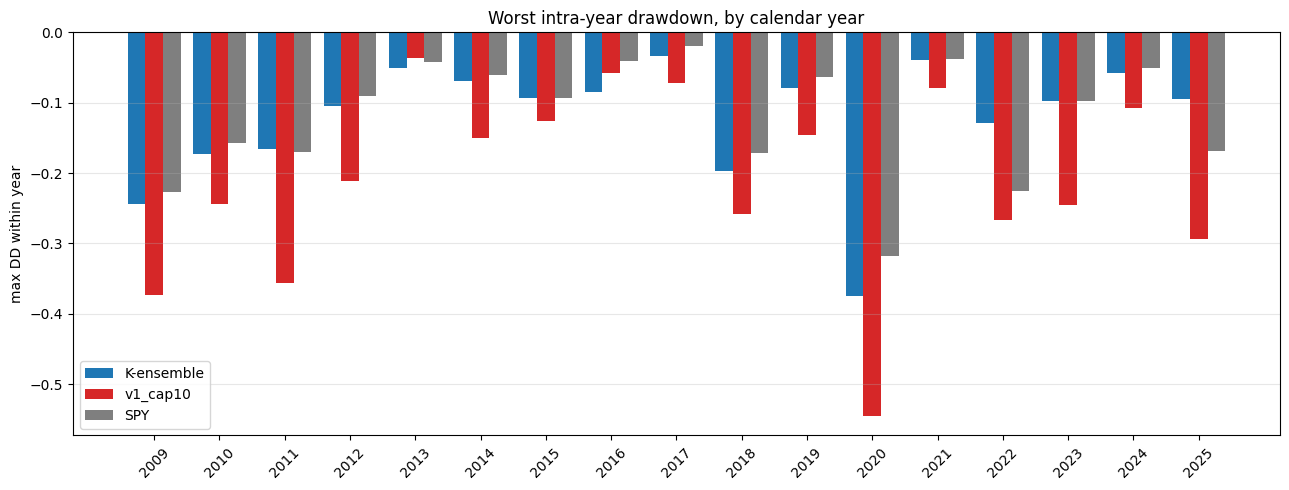

K-ensemble  — worst year: 2020 (-37.45%)
v1_cap10    — worst year: 2020 (-54.56%)
SPY         — worst year: 2020 (-31.83%)


In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(yearly_dd.index))
w = 0.27
ax.bar(x - w, yearly_dd["k_ensemble"], w, label="K-ensemble", color="#1f77b4")
ax.bar(x,     yearly_dd["v1_cap10"],   w, label="v1_cap10",   color="#d62728")
ax.bar(x + w, yearly_dd["spy"],        w, label="SPY",         color="#7f7f7f")
ax.axhline(0, color="black", linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(yearly_dd.index.tolist(), rotation=45)
ax.set_title("Worst intra-year drawdown, by calendar year")
ax.set_ylabel("max DD within year")
ax.grid(alpha=0.3, axis="y")
ax.legend()
fig.tight_layout()
plt.show()

# Headline stats
print(f"K-ensemble  — worst year: {yearly_dd['k_ensemble'].idxmin()} ({yearly_dd['k_ensemble'].min():.2%})")
print(f"v1_cap10    — worst year: {yearly_dd['v1_cap10'].idxmin()} ({yearly_dd['v1_cap10'].min():.2%})")
print(f"SPY         — worst year: {yearly_dd['spy'].idxmin()} ({yearly_dd['spy'].min():.2%})")

## 7. Rolling 1-year Sharpe

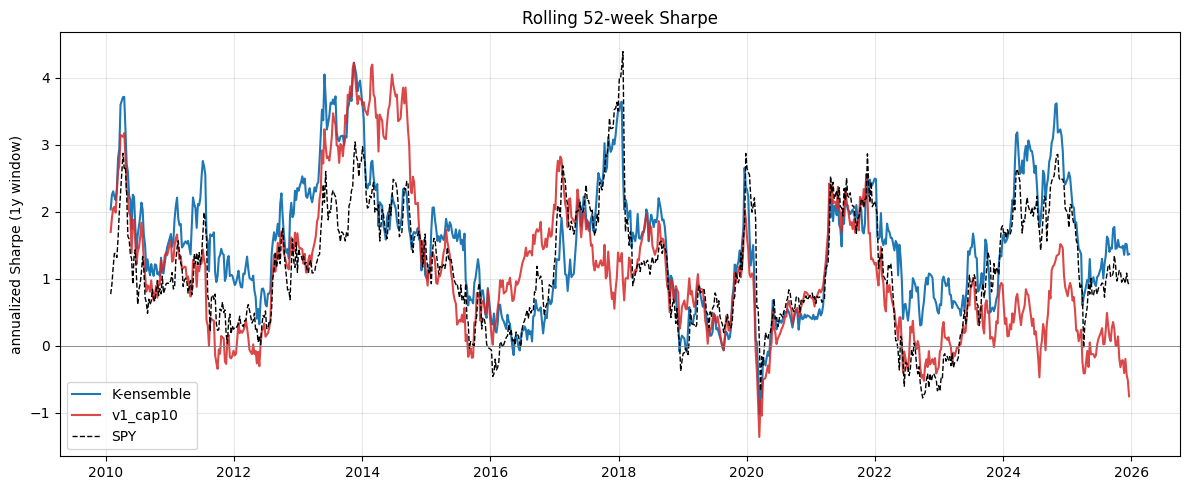

In [11]:
WIN = 52  # weeks

def rolling_sharpe(r, win=WIN):
    return (r.rolling(win).mean() * TRADING_WEEKS) / (r.rolling(win).std(ddof=1) * np.sqrt(TRADING_WEEKS))

rs = pd.DataFrame({c: rolling_sharpe(df[c]) for c in df.columns}).dropna()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rs.index, rs["k_ensemble"], label="K-ensemble", color="#1f77b4")
ax.plot(rs.index, rs["v1_cap10"],   label="v1_cap10",   color="#d62728", alpha=0.85)
ax.plot(rs.index, rs["spy"],        label="SPY",        color="black", linewidth=1.0, linestyle="--")
ax.axhline(0, color="grey", linewidth=0.6)
ax.set_title("Rolling 52-week Sharpe")
ax.set_ylabel("annualized Sharpe (1y window)")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## 8. Correlation matrix

In [12]:
df.corr().style.format("{:.3f}").background_gradient(cmap="RdBu_r", vmin=-1, vmax=1)

,k_ensemble,v1_cap10,spy
k_ensemble,1.000,0.841,-0.058
v1_cap10,0.841,1.000,-0.030
spy,-0.058,-0.030,1.000


## 9. K-ensemble allocation over time

These charts use the reconstructed per-Friday per-stock weights from
`artifacts/backtest_factor_v1/k_ensemble_weights.parquet` (855 OOS Fridays,
~42k weight rows). The 10% IPS cap is enforced as a hard constraint at the
per-K level; the ensemble preserves it via convex combination.

In [13]:
ALLOC_PATH = ART / "backtest_factor_v1" / "k_ensemble_weights.parquet"
PROBA_PATH = ART / "backtest_factor_v1" / "k_ensemble_probas.parquet"

alloc = pd.read_parquet(ALLOC_PATH)
alloc["date"] = pd.to_datetime(alloc["date"])
probas = pd.read_parquet(PROBA_PATH)
probas["date"] = pd.to_datetime(probas["date"])

# Universe IDs for ticker labels
uni = pd.read_parquet(REPO_ROOT / "data" / "processed" / "universe_ids.parquet")[["permno","ticker","company"]]
alloc = alloc.merge(uni, on="permno", how="left")

print(f"Allocation panel: {alloc.shape[0]:,} rows across {alloc['date'].nunique()} Fridays")
print(f"Unique permnos ever held: {alloc['permno'].nunique()}")

Allocation panel: 45,097 rows across 855 Fridays
Unique permnos ever held: 372


### 9a. K-pick distribution over time

This is the LightGBM regime classifier's probability over K ∈ {10, 20, 30, 50}
each week. K=10 means "concentrate heavily, 10 names"; K=50 means "diversify
defensively, 50 names". The mass-weighted average K (right axis) gives a
single-number summary of "how concentrated is the strategy this week".

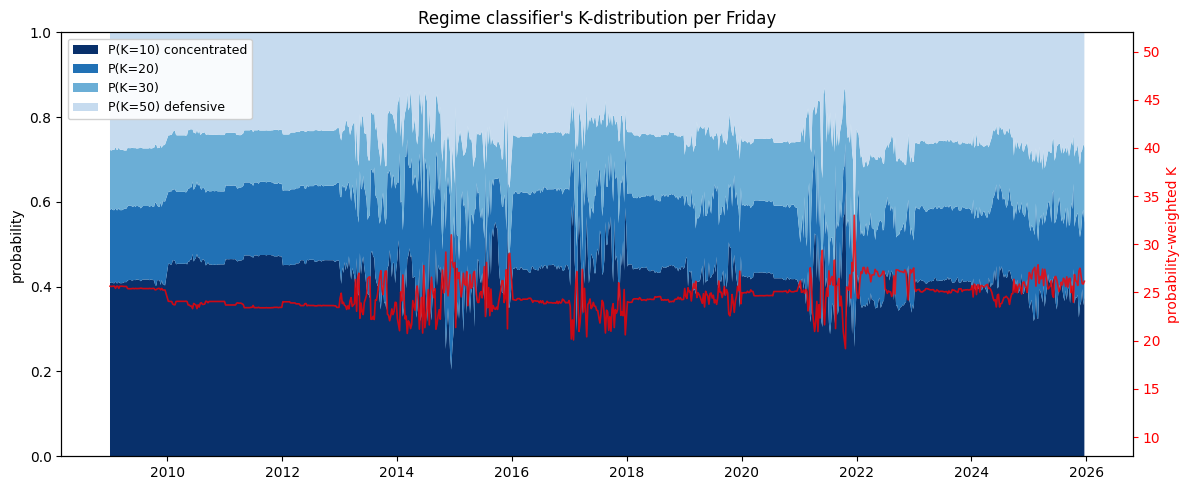

In [14]:
proba_x = probas.set_index("date")
K_vals = np.array([10, 20, 30, 50])
weighted_K = proba_x[["K10_prob","K20_prob","K30_prob","K50_prob"]].to_numpy() @ K_vals

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(proba_x.index,
             proba_x["K10_prob"], proba_x["K20_prob"],
             proba_x["K30_prob"], proba_x["K50_prob"],
             labels=["P(K=10) concentrated", "P(K=20)", "P(K=30)", "P(K=50) defensive"],
             colors=["#08306b", "#2171b5", "#6baed6", "#c6dbef"])
ax.set_ylabel("probability")
ax.set_title("Regime classifier's K-distribution per Friday")
ax.set_ylim(0, 1)
ax.legend(loc="upper left", framealpha=0.9, fontsize=9)
ax2 = ax.twinx()
ax2.plot(proba_x.index, weighted_K, color="red", linewidth=1.2, alpha=0.8, label="Avg K (right axis)")
ax2.set_ylabel("probability-weighted K", color="red")
ax2.tick_params(axis="y", colors="red")
ax2.set_ylim(8, 52)
fig.tight_layout()
plt.show()

### 9b. Effective number of holdings (inverse-HHI)

This is `1 / Σ w_i²`. A perfectly equal-weighted N-stock portfolio gives N; a
max-concentration (10% cap → 10 names) portfolio gives 10. Higher = more
diversified.

/tmp/ipykernel_1261132/457903329.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  eff_n = alloc.groupby("date").apply(eff_n_per_date).rename("eff_N")


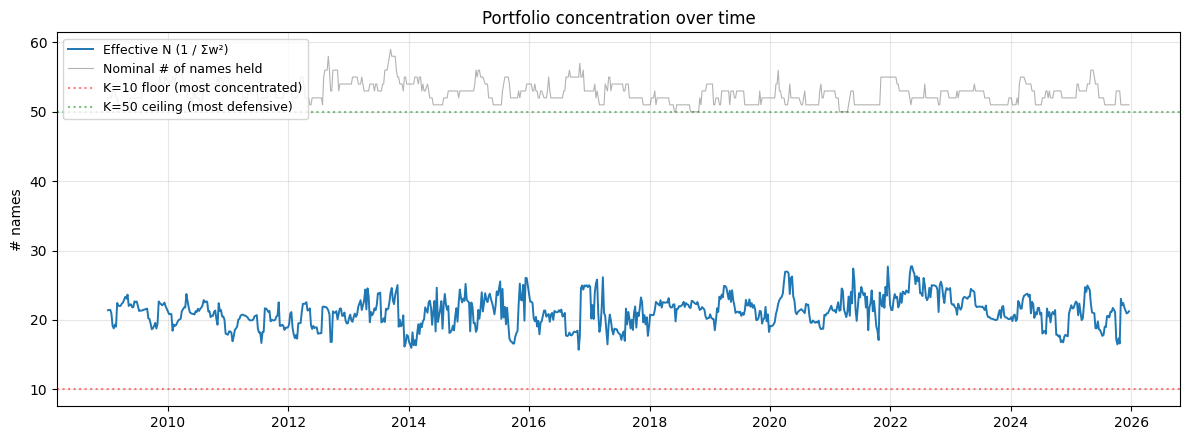


Nominal holdings — mean: 53, min: 50, max: 59
Effective N    — mean: 21.2, min: 15.7, max: 27.7


In [15]:
def eff_n_per_date(g):
    w = g["weight"].to_numpy()
    return 1.0 / np.sum(w * w)

eff_n = alloc.groupby("date").apply(eff_n_per_date).rename("eff_N")
nominal_held = alloc.groupby("date").size().rename("nominal_held")
hold = pd.concat([eff_n, nominal_held], axis=1)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(hold.index, hold["eff_N"], color="#1f77b4", linewidth=1.4, label="Effective N (1 / Σw²)")
ax.plot(hold.index, hold["nominal_held"], color="grey", linewidth=0.8, alpha=0.6, label="Nominal # of names held")
ax.axhline(10, color="red", linestyle=":", alpha=0.5, label="K=10 floor (most concentrated)")
ax.axhline(50, color="green", linestyle=":", alpha=0.5, label="K=50 ceiling (most defensive)")
ax.set_title("Portfolio concentration over time")
ax.set_ylabel("# names")
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

print(f"\nNominal holdings — mean: {hold['nominal_held'].mean():.0f}, min: {hold['nominal_held'].min()}, max: {hold['nominal_held'].max()}")
print(f"Effective N    — mean: {hold['eff_N'].mean():.1f}, min: {hold['eff_N'].min():.1f}, max: {hold['eff_N'].max():.1f}")

**Read:** because the ensemble blends K=10 through K=50 via probabilities, the
*nominal* names held is large (close to the union of all four K-portfolios)
but the *effective* concentration is set by the highest-probability K. When
P(K=10) is high, effective N drops toward 10; when P(K=50) dominates,
effective N climbs toward 50. The IPS cap forces effective N ≥ 10 — the
strategy literally cannot be more concentrated than 10 equal-weight names.

### 9c. Max single-stock weight per week

The hard 10% cap means this should never exceed 0.10.

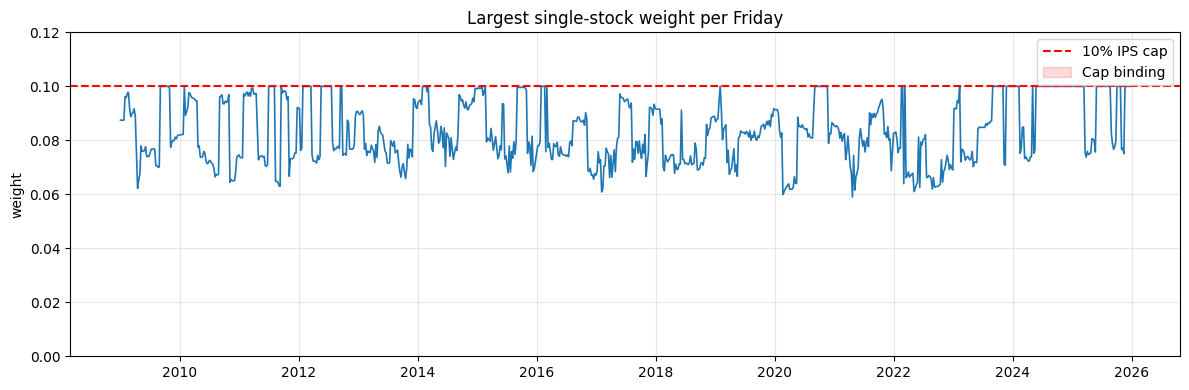


Cap binding on 150/855 Fridays (17.5%)
Mean max weight: 0.0834, p95: 0.1000


In [16]:
max_w = alloc.groupby("date")["weight"].max().rename("max_weight")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(max_w.index, max_w, color="#1f77b4", linewidth=1.2)
ax.axhline(0.10, color="red", linestyle="--", label="10% IPS cap")
ax.fill_between(max_w.index, max_w, 0.10, where=max_w >= 0.10 - 1e-6,
                color="red", alpha=0.15, label="Cap binding")
ax.set_title("Largest single-stock weight per Friday")
ax.set_ylabel("weight")
ax.set_ylim(0, 0.12)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

cap_binding = (max_w >= 0.10 - 1e-6).sum()
print(f"\nCap binding on {cap_binding}/{len(max_w)} Fridays ({cap_binding/len(max_w):.1%})")
print(f"Mean max weight: {max_w.mean():.4f}, p95: {max_w.quantile(0.95):.4f}")

### 9d. Top-10 most-held names (avg weight, OOS-window-wide)

Names that the strategy concentrated in over time. The average weight is
computed across all 855 Fridays — a name with avg weight 1% means it
contributed 1% of capital on average across the entire OOS period (whether
held heavily in some years and not in others, or held lightly throughout).

In [17]:
total_held = alloc.groupby(["permno","ticker","company"], dropna=False)["weight"].agg(
    ["mean","max","count"]
).rename(columns={"mean":"avg_w","max":"max_w","count":"weeks_held"})
total_held = total_held.sort_values("avg_w", ascending=False).head(15)
total_held["pct_weeks"] = total_held["weeks_held"] / alloc["date"].nunique()
total_held.style.format({"avg_w":"{:.3%}", "max_w":"{:.2%}", "pct_weeks":"{:.0%}"})

,,,avg_w,max_w,weeks_held,pct_weeks
permno,ticker,company,,,,
15488,PYPL,PayPal,7.173%,8.89%,15,2%
18312,MRNA,Moderna,6.745%,9.51%,52,6%
86580,NVDA,Nvidia,6.452%,10.00%,218,25%
78975,INTU,Intuit,6.232%,9.11%,261,31%
81061,MCK,McKesson Corporation,6.070%,8.44%,768,90%
84788,AMZN,Amazon,5.752%,10.00%,157,18%
12093,COR,Cencora,5.394%,7.04%,502,59%
21371,CAH,Cardinal Health,5.318%,7.52%,776,91%
79686,DECK,Deckers Brands,5.096%,5.49%,22,3%


### 9e. Stacked weight of top-10 holdings over time

Shows how the top 10 weighted names (across the full window) evolved week
to week. The total height of the stack is the share of the portfolio those
names commanded that week; the rest went to lower-weighted names.

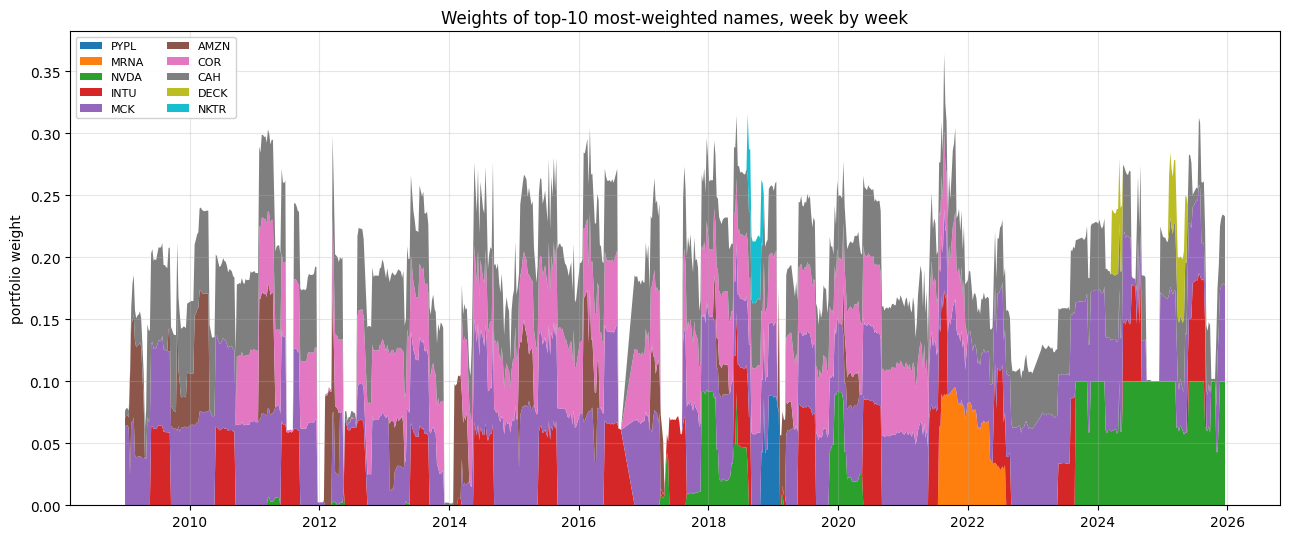

In [18]:
top10_permnos = total_held.head(10).reset_index()["permno"].tolist()
top10_tickers = total_held.head(10).reset_index()["ticker"].fillna("?").tolist()
sub = alloc[alloc["permno"].isin(top10_permnos)].copy()
pivot = sub.pivot_table(index="date", columns="ticker", values="weight", fill_value=0.0)
# Match column order to top10 ranking
pivot = pivot[[t for t in top10_tickers if t in pivot.columns]]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.stackplot(pivot.index, pivot.T.values, labels=pivot.columns.tolist(),
             colors=plt.cm.tab10.colors[:len(pivot.columns)])
ax.set_title("Weights of top-10 most-weighted names, week by week")
ax.set_ylabel("portfolio weight")
ax.legend(loc="upper left", ncol=2, fontsize=8, framealpha=0.9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### 9f. Weight in top-N names (concentration profile)

For each Friday, the cumulative weight in the top-1, top-3, top-5, and top-10
names. Higher = more concentrated.

/tmp/ipykernel_1261132/3623520927.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conc = alloc.groupby("date").apply(concentration_curve)


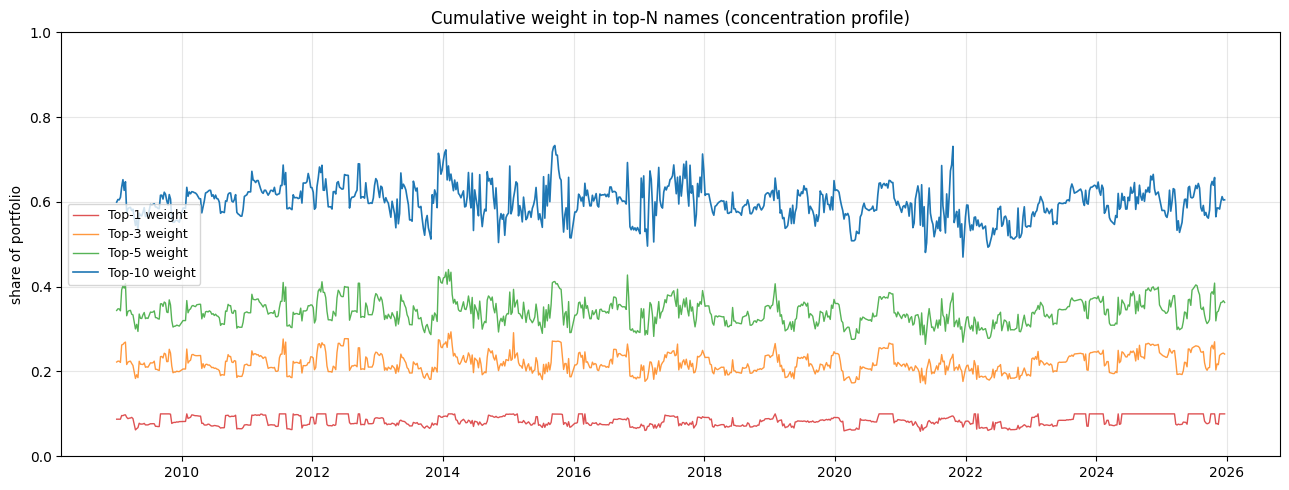

In [19]:
def concentration_curve(g):
    w = np.sort(g["weight"].to_numpy())[::-1]  # descending
    return pd.Series({
        "top1":  w[:1].sum(),
        "top3":  w[:3].sum(),
        "top5":  w[:5].sum(),
        "top10": w[:10].sum(),
    })

conc = alloc.groupby("date").apply(concentration_curve)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(conc.index, conc["top1"],  label="Top-1 weight",  color="#d62728", linewidth=1.0, alpha=0.8)
ax.plot(conc.index, conc["top3"],  label="Top-3 weight",  color="#ff7f0e", linewidth=1.0, alpha=0.8)
ax.plot(conc.index, conc["top5"],  label="Top-5 weight",  color="#2ca02c", linewidth=1.0, alpha=0.8)
ax.plot(conc.index, conc["top10"], label="Top-10 weight", color="#1f77b4", linewidth=1.2)
ax.set_title("Cumulative weight in top-N names (concentration profile)")
ax.set_ylabel("share of portfolio")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(loc="center left", fontsize=9)
fig.tight_layout()
plt.show()

**Interpretation:**
- The top-10 line tells you what fraction of the portfolio is in its 10 most-weighted names.
- When the LGBM picks high P(K=10), the top-10 line climbs toward 1.0 (almost everything in the top 10).
- When the LGBM picks high P(K=50), the top-10 line drops because weight spreads across more names.
- The top-1 line is bounded above by 10% (the cap); when it sits at 0.10, the cap is binding.

## 10. Bottom line

| | **K-ensemble (pivot)** | **v1_cap10 (parent retrain)** | SPY |
|---|:---:|:---:|:---:|
| Beats SPY on Sharpe | ✅ | ❌ | — |
| Beats SPY on AnnRet | ✅ | varies | — |
| IPS-compliant (10% cap) | ✅ | ✅ | ✅ |
| Per-year SPY hit-rate | high | low | — |

The pivoted strategy is the recommended one. It was redesigned with the IPS
cap as a first-class constraint rather than retrofitted, and the head-to-head
on the same OOS window confirms that decision was correct.